## Unsupervised Learning:

Previously, we worked with problems and data samples that had labels, and the models we used relied on these labels to make predictions. However, in reality, most available data is unlabeled—we do not know their categories, only some of their features. To analyze such data, we use **Unsupervised Learning** approaches.

+ **Definition:**

    Unsupervised learning involves analyzing unlabeled data to discover hidden patterns or structures within the data. And it helps us to be able to use data that have not been labeled.

> In problems that get solved using unsupervised learning approaches labeling the data we've got is the high-cost part of the procedure of learning.

**Common clustering tasks and problems that we deal with**:

+ **Clustering**: Grouping data points into clusters based on similarity
+ **Dimension Reduction**: Reducing the number of features under consideration and keeping (almost approximately) the most informative features.
+ **Anomaly Detection**: Identifying data pints that deviate significantly from norm (e.g., fraud detection, alerts(could be any one of them that has happened based on an unregulairty))
+ **Generative Modeling**: Learning the **distribution** of data to generate new, similar instances.

`In this notebook we want to dig into clustering`

## Clustering

Clustering is an unsupervised ML algorithm that **organizes** and **classifies** different objects, data points, or observations into groups or clusters based on similarities or patterns.

> "The notion of similarity depends on the task at hand (e.g., purchase behavior in market segmentation)."

**Real-life applications of clustering include:**
- Customer segmentation in marketing
- Image segmentation in computer vision
- Document or news article categorization
- Anomaly detection in network security
- Grouping genes with similar expression patterns in bioinformatics
- Recommender systems (grouping users/items by behavior)
- Social network analysis (community detection)
- Organizing large datasets for efficient retrieval and analysis


We have many different types of clustering as there are multiple ways to define a cluster. Different approaches will work well for different types of models depending on the size of the input data, the dimensionality of the data, the rigidity of the categories and the number of clusters within the dataset, It's worth noting that one algorithm may work very well for one dataset and very poorly on another:

+ **Centroid-based clustering**
+ **Hierarchial clustering**
+ **Distribution-based clustering**
+ **Density-based clustering**
+ **Grid-based clustering**


Now what we should do is to find a way for the two problems below:

+ How to create a good cluster?
+ How many  clusters do we need?

### K-Means:

K-Means is one of the most common used centroid-based clustering algorithms. In this technique, K-Means assumes that the **center** of each cluster defines the cluster Using a distance measure, mostly commonly Euclidean distance, to the centroid.<br>
It's purpose is to partition data into *K* distinct clusters based on the features **similarity**.<br>
How it works is basically like this: We choose some random cnetroids as the center of our *K* clusters and then **Iteratively** assign data points to the nearest centroid (means of the group) and then recalculate the centroid based on the new group memberships. The process repeats until the assignments no longer change.

It's algorithm:

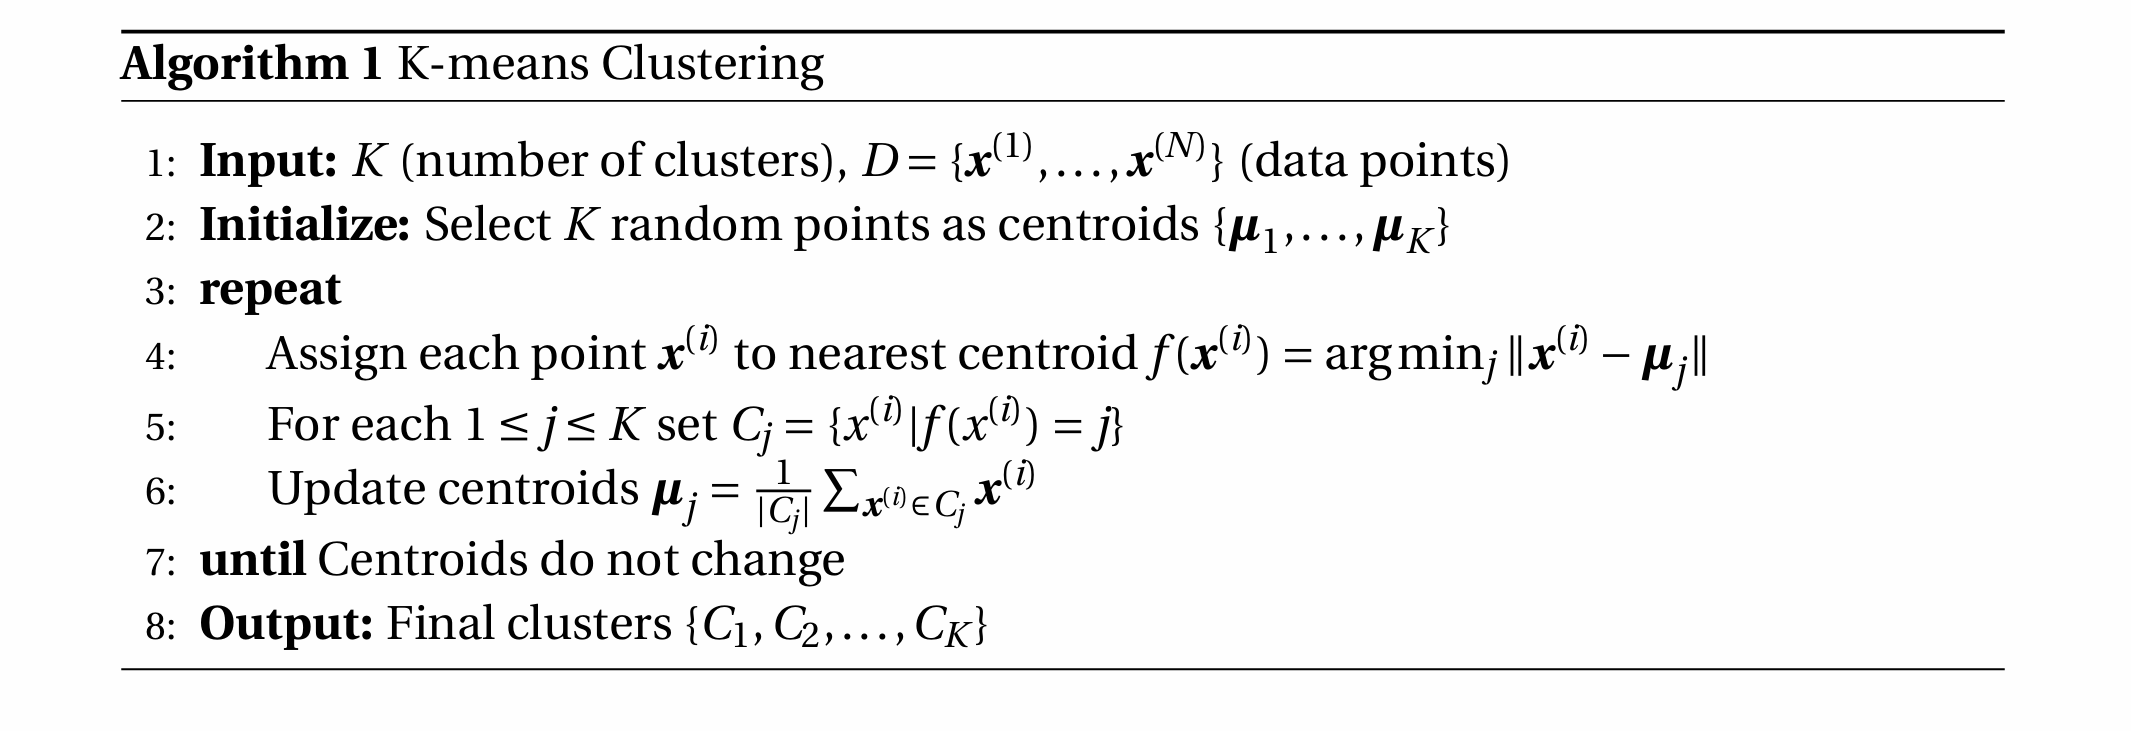
<center>Figure 1: K-Means algorithm, Adopted from [2]</center>
<br>

So we have a train dataset:

$$X_{train} = \{x^{(1)}, x^{(2)}, ..., x^{(N)}\} \subseteq R^d$$

And we've got a $K$ which is the number of the clusters.

What we're learning:
1. A function or a mapping: $f: R^d \rightarrow \{1, 2, ..., K\}$ that assigns a cluster to each data point.
2. A set of $K$ prototypes $\mu = \{\mu_1, \mu_2, ..., \mu_K\} \subseteq R^d$ as the cluster representatives, called **Centeroids**

> Our purpose is to create segmentation of data points in clusters such that that segmentation be optimal.

We have bunch of data points and we wanna segment them into clusters 1, 2, ...., k such that the sum of data point's distance from their cluster's centroid to be the minimum value possible. 

The proposition above gets formulzed as the formula below which is kind of the cost function of K-Means and we wanna minimize it:

$$J = \sum_{j=1}^{K} \sum_{x^{(i)} \in C_j} ||x^{(i)} - \mu_j||^2$$

So we have to choose an $f$ (mapping) and $\mu = \{\mu_1, \mu_2, ..., \mu_k\}$ such that the equation above gets optimal(minimum value possible).

The thing we want in simple terms is that we want to assing data points to clusters such that the function $J$ gets minimum. But this is an **NP-hard** problem which means that there's no polynomial algorithm for (at least yet) that guarantees to give us the optimal solution.<br>

So K-Means will not necessarily result the optimal solution. And we can say that K-Means is a heuristic algorithm, and it may stuck in a local optimum and do not result in global optimum.

+ So the question here is that does K-Means get converge? and by *converge* we mean that does it get out of the optimization loop and reach to a minimum in it's algorithm or it will stuck in the loop forever?

> The answer to the question above is YES. In the below section we're gonna see why.

#### Convergence:

Earlier we defined a function $J$ which  is the sum of the distnaces of each samples to it's cluster's centroid, and we wanna prove taht teh $J$ function decreases every time that the update loop of K-Means algorithm runs and it cannot get lower than zero and have infinite number of conditions.<br>

+ Something we have to prove first is that the $J$ will have infinite numbers of values/states given a finite set:

    If we were given any amount of data, They're assignment to each cluster has finite states, meaning that when we wanna add a data point to a one of our clusters, knowing we have `K` clusters, has `K` states that data ponint can get add to, So having *N* data points makes the states and conditions possible for assigning data points to cluster less than equal to $K^N$. So states cannot have more than $K^N$ **permutation** in the feature space we're having so we can conclude from that the number of valeus possible for the $J$ also cannot exceed $K^N$.<br>
    So we draw conclusion from this that if $J$ decreases in the algorithm, in a finite set, it will get to a minimum and comes out of the loop and the algorithm ends.


Now let's get to the proof of that $J$ decreases after each iteration of the algorithm's loop.<br>
There are two way of proving the convergence of K-Means algorithm:

1. **Proof 1(Descriptive proof)**:

+ So initially we have some random centroid and we assign each sapmple to the nearest centroid:

$$f(x):=\argmin_{j} ||x - \mu_j||^2$$
<center>Adopted from [2]</center>

Then we keep each sample's assignment **fixed** until a **closer** centroid is found. This doesn't apply to equal distance, if in moving centroids the distance of a sample get equal between two centroids, it's centroid and cluster would not change, otherwise if the sample find a distance to a centroid which is smaller than it's previous distance to another centroid, it will change clusters and according to the formula of $J$ we have now seen a decrease in distance and this will lead to decrease of $J$.

+ Each time a sample is reassigned. The **total distance** between samples and their centroid **decreases** .
+ The number of possible sample-to-centroid assignment is finite(have been proved above)
+ And the algorithm terminates when no sample changes its assigned centroid.


2. **Proof 2(Mathematical proof)**

+ In updating step, with mapping function $f(x)$ being fixed, $J$ is a quadratic function of $\mu_j$ (like SSE) and by taking derivative we can minimize it as:

$$\frac{\partial J}{\partial \mu_j} = \sum_{x^{(i)} \in C_j} 2(x^{(i)} - \mu_j) = 0$$

+ This means that we should **update** each $\mu_j$ as the mean of cluster $C_j$:

    $$\mu_j = \frac{\sum_{x^{(i)} \in C_j} x^{(i)}}{|C_j|}$$

    + $|C_j|$: number of cluster's samples(cause $\mu_j$ is being repeated to the number of cluster's samples)
 
> The above equation is saying that the sample that is goign to make the cost function minimum is the mean of the samples of a cluster(for each cluster obviously)

+ For each cluster, the mean of its samples minimizes squared distance.
+ For $C_j$ if $\mu_j'$ was the old centroid we have: $\sum_{x^{(i)} \in C_j} ||x^{(i)} - \mu_j'||^2 \geq \sum_{x^{(i)} \in C_j} ||x^{(i)} - \mu_j||^2$. So $J_{new} \leq J_{old}$


The thing we're telling is:

The centroid or $\mu$ of each cluster in the process of algorithm changes, and we have proven that if $\mu$ was the previous centroid of the cluster and $\mu'$ is the new centroid of the cluster due to the mean of the cluster's samples after update in the algorithm's loop.<br>
We have proven that the sum of the cluster's sample's distance with new centroid $\mu'$ is smaller than the cluster's sample's distance with the previous centroid $\mu$. This means the convergence of $J$ .

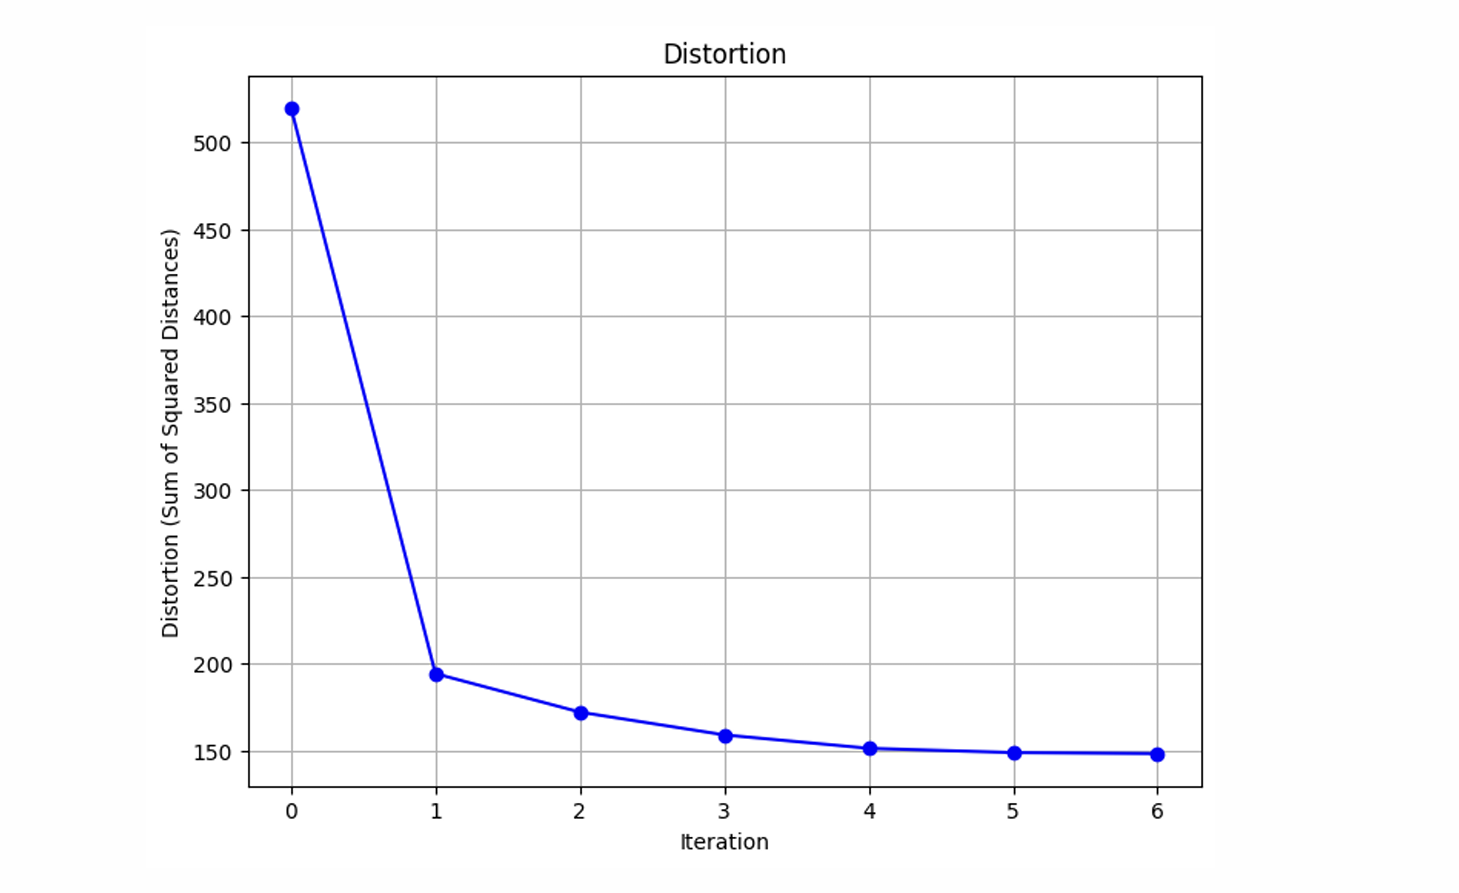
<center>Figure 2: Distortion's convergence, Adopted from [2]</center>

### Challenges in K-Means

##### Challenge 1:

As mentioned before K-Means global optimality is an NP-hard problem, thus it makes K-Means a **heuristic** method. But what does it mean when we say a method or an algorithm is heuristic:

+ **What is a Heuristic?**

    It is a practical method or rule of thumb. And it is not guaranteed to find the *optimal* solution. And it is designed to find a *good enough* solution within a *reasonable* amount of time. And it is often used when the problem is too complex(NP-hard).

    So what does it mean when we say that K-Means is a heuristic:
    + It does not explore **all** possible clusterings. (It takes a lot of time).
    + It uses a **greedy, iterative approach** to quickly find a reasonable good solution.
    + The output depends highly on the **initialization**, and might get stuck in a **local minimum**.

There are ways to solve this challenge:
+ Multiple runs with **random Initial centroids**, then select the "best" result.
+ To some how solve the initialization, we have the initialization heuristics: **K-Means++**, **Furthest Traversal**

> Mostly solving the challege 1 is fixing the initialization and hope for a better initialization so we get more hopefull of reaching to global minimum.

+ **K-Means++ Initialization**:

    As we know random initialization of centroid is very risky and It may lead us to a local minimum result, To solve this problem K-Means++ was introduced which improves the way initial cluster centers are selected and make the clustering results more accurate and faster.<br>
    By not randomly initialized centroids we're avoiding of putting multiple centers in dense regions and none in sparse ones.
    
    > The key idea behind K-Means++ is that it chooses the initial cluster centers in a smart way to ensure they are spread out which helps the algorithm converge **faster** and gives **better clustering results**.<br>
    > — [Adopted from [3]](https://www.geeksforgeeks.org/machine-learning/ml-k-means-algorithm/)

    How it works:

    1. Initialization Step:
        - Choose the **first** cluster **randomly**.
        - For each remaining cluster center select the next center based on the **probability** that is proportional to the square of the distance between the data point and the closest selected center. After calculating probabilities, we would pick the next center **randomly, but** biased toward points that are farther from existing centers.
    2. Clustering Step:
        - After selecting the initial centers K-Means++ performs clustering the same way as K-Means.


+ **Furthest-first Traversal(Gonzalez's algorithm):**

    This initialization algorithm is similar to K-Means++ but is **deterministic** (not probabilistic like K-Means++) and often used when you want **maximum center spread**.

    It is a **greedy deterministic** method for selecting $k$ initial centers by **always** picking the point **furthest from all previously chosen centers**.

    How does it work:<br>   
    1. Let's say we want to select $k$ cluster centers from dataset: $X = \{x_1, x_2,..., x_n\}$
    - We pick the **first** center arbitrarily(often random)
    - For each subsequent center (from to $k$):
    2. For each subsequent center (from 2 to $k$):
    - Compute the **distance from each point** to the neareset **center already chosen**.
    - Pick the point with the **maximum** such distance.
    - Add this point as the next center.

##### Challenge 2:

Not all our data smaples are able to calculate a mean from them to update the centroids, like categorial data samples. There is an alternative that we can use is the **mode** and use the **K-Modes** method.<br>

+ **K-Mode**: 

    The centroid is the most frequent category in each cluster. And the closest centroid is found by the **Hamming Distance**.<br> 
    The K-Modes clustering partitions the data into two mutually exclusive groups. Unlike K-Means which uses distance between numbers K-Modes uses the number of mismatches between categorical values to decide how similar two data points are. 

    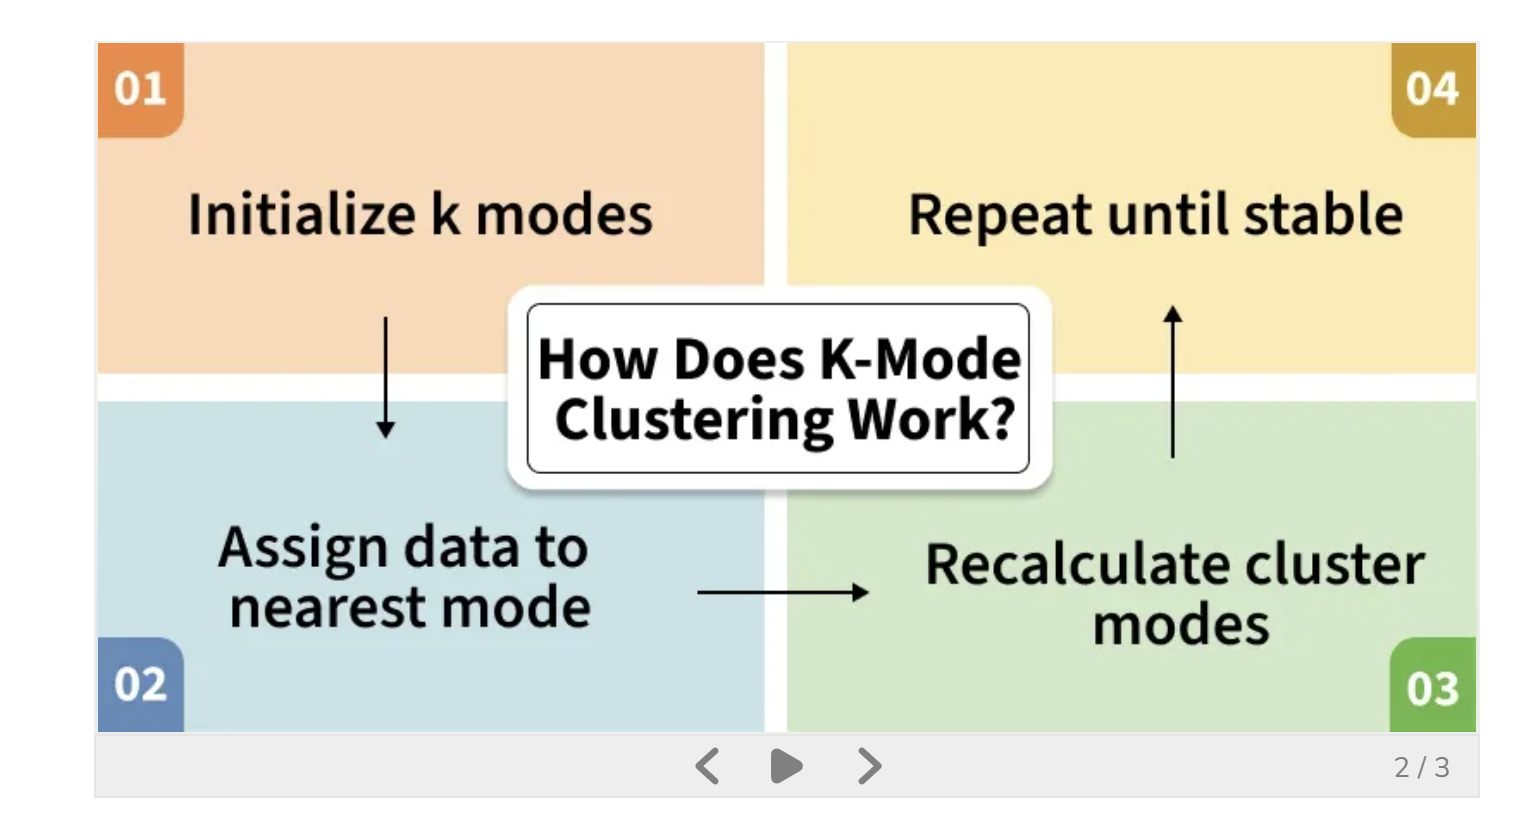
    <center>Figure 3: K-Modes algorithm's steps, Adopted from[4]</center>

    **How K-Modes clustering works?**:

    > Unlike hierarchical clustering KModes requires us to decide the number of clusers (K) in advance.<br>
    > — [Adopted from [4]](https://www.geeksforgeeks.org/machine-learning/k-mode-clustering-in-python/)

    + Start by picking clusters: *Randomly* select K data points from the dataset to act as the starting clusters(we call these "modes).
    + Assign data to clusters: Check how similar each data point is to these clusters using the total number of mismatches and assign each data point to the cluster it matches the most.
    + Update the clusters: Find the most common value for each cluster and update the cluster centers based on this.
    + Repeat the process: We keep repeating the two steps above until no data points are reassigned to different clusters.

    > For checking the similarities between data points and how much they're different from each other we use **Hamming distance** algorithm, in which we add 1 for a dissimilarity in comparing a feature of two data points and add nothing(0) if they're the same and we do this for all of the features of two individual data points and then we sum all of the resulted numbers and we see that the more bigger the summed numbers are the more different are data points from each other and the more smaller the summed numbers are data points are more similar.

    For better understanding of how K-Modes works, watch [this](https://www.youtube.com/watch?v=b39_vipRkUo) video.

    Mathematical explain:
    <br>

    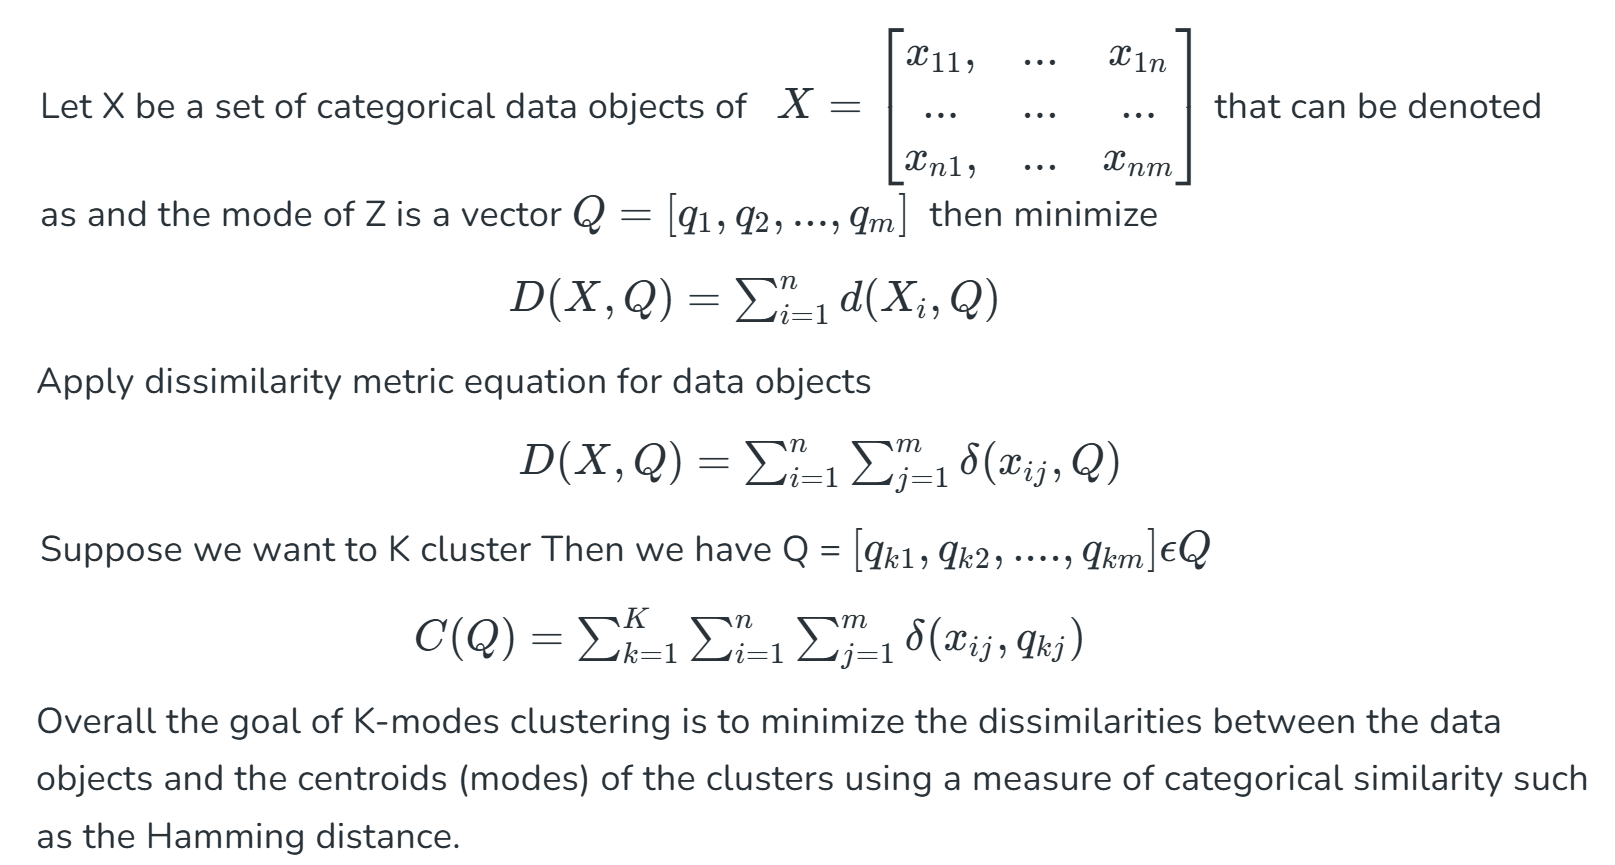
    <center>Adopted from [4]</center>
    <br>


##### Challenge 3:

The next challenge in using K-Means is the number of clusters and optimal value for `k`. If we set `k` too low we're forcing **very different** groups into the same cluster. And if we set `k` too high we're forcing splits within **natural clusters**, breaking one group into many subclusters.

For finding the optimal (or at least close to optimal) number of clusters, we need to know how we can evaluate a clustering. Evaluating clusters involves two key aspects:

+ **Intra-cluster cohesion(compactness)**:

    This aspect checks how similar the data points are within a cluster, and for a visualizing better it checks how much a cluster's smaples are close to the centroid of the cluster. The more compact/similar samples of a cluster is the more better that cluster is.<br>
    This aspect is often measure by the *within-cluster sum of squares(WCSS)*:

    $$WCSS = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$
    <center>Adopted from [2]</center>
    <br>


+ **Inter-cluster cohesion(isolation)**:

    This aspect evaluates how well-separated the clusters are from each other — in other words, how different or distant the data points in one cluster are from those in another. Better isolation means the clustering algorithm has cleanly separated distinct groups.

    There are several numerical metrics we can use to evaluate inter-cluster isolation:

    + **Single-link(Minimum Distance)**: This metric measures the minimum distance between any two points in different clusters:
    $$d_{signle}(C_i, C_j) = \min_{x \in C_i, y \in C_j} d(x, y)$$
    <center>Adopted from [2]</center>
    <br>

    > Measures **the closest** between two clusters.<br>
    > Small values indicate that clusters might be **too close or even touching**.

    + **Complete-link(Maximum Distance)**: This measures the maximum distance between any two points in different clusters:
    $$d_{complete}(C_i, C_j) = \max_{x \in C_i, y \in C_j} d(x, y)$$
    <center>Adopted from [2]</center>
    <br>

    > Reflect the **worst-case separation**. Large values suggest clusters are **well-separated** in their farthest points.

    + **Centroid (wards method)**: It measures the distance between the centroids of two clusters. 
    $$d_{centroid}(C_i, C_j) = d(\mu_i, \mu_j)$$
    <center>Adopted from [2]</center>
    <br>

    > Measures the separation between the central tendencies of clusters, ignoring their shapes or spreads.

    + **Average-link**: Measures the average distance between all pairs of points from different clusters:
    $$d_{average}(C_i, C_j) = \frac{1}{|C_i|.|C_j|} \sum_{x \in C_i}\sum_{y \in C_j} d(x, y)$$
    <center>Adopted from [2]</center>
    <br>

    > Provides a balanced view of how two clusters relate on average, smoothing out outliers.Provides a balanced view of how two clusters relate on average, smoothing out outliers.

> Now we're able to use the two concept above and find the most optimal `k`, in a way that it compact each cluster and isolate clusters from each other and they they have a good distance from each other.


There is an **Elbow Method** for the optimal `K`:

+ **Elbow Method**:

    Finds the optimal *number* of clusters `K` by **minimizing** the within-cluster sum of squares(WCSS). If we minimize the WCSS and plot it's values among this minimization versus `K`, There will be a part in plot that is named **Elbow Point**, It is where the *rate* of decrease **sharply** slows down (resembles an "elbow") is considered the optimal `K`

    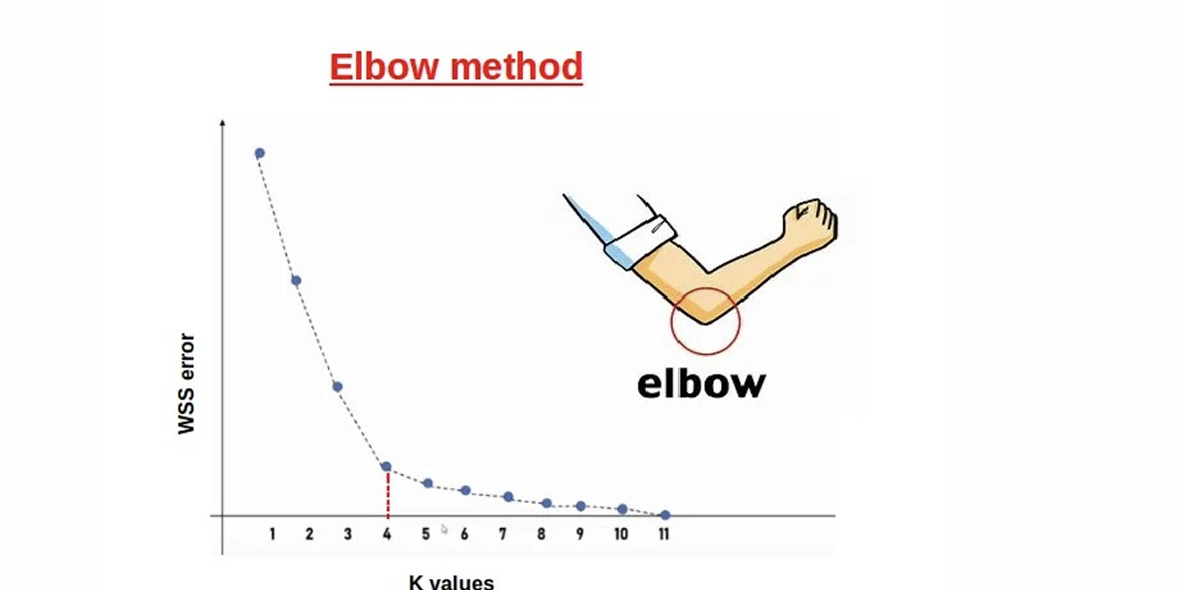
    <center>Figure 4: Elbow Method, Adopted from [2]</center>


There is another way for cluster evaluation called **Silhoute Method**:

+ **Silhouette Method**:

    The silhouette score for each data point tells us:<br>
    > How well does this point fit in its assigned cluster compared to others clusters?<br>
    It captures the **compactness** of a cluster and its **separation** from other clusters — combining **intra-cluster cohesion** and **inter-cluster separation**<br>
    Formula:
    $$S(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

    + $a(i)$: average distance from point $i$ to **all other points in its own cluster. (Intra-cluster distance)
    + $b(i)$: minimum average distance from ponint $i$ to **all points in the dataset cluster** that $i$ is not a part of(nearest-cluster distance)

    Obviously the value of $s(i) \in [-1, 1]$.

    + If $s(i) ≈ -1$: Point is likely **misclassified**, and assigned to the wrong cluster.
    + If $s(i) ≈ 0$: Point is on the **border** of two clusters.
    + If $s(i) ≈ 1$: Point is well-matched to its cluster and **far** from others, It is the ideal scenario.


> There is a trade off between having better focus within each cluster or having too many clusters. 

+ **Optimization Problem**: Penalize having too many cluster with the equation below:
    $$K^* = \argmin_{k} [J(k) + \lambda k]$$
    + $J(k) \rightarrow$ It is the WCSS. It decreases as $k$ increases
    + $\lambda \rightarrow$ It is a regularization parameter, it controls how much we penalize having more clusters.
    + $\lambda k \rightarrow$ The penalty for using `k` clusters. Prevents the model choosing a high `k` just to reduce $J(w)$

    The above formula is a classic bias-variance tradeoff:

    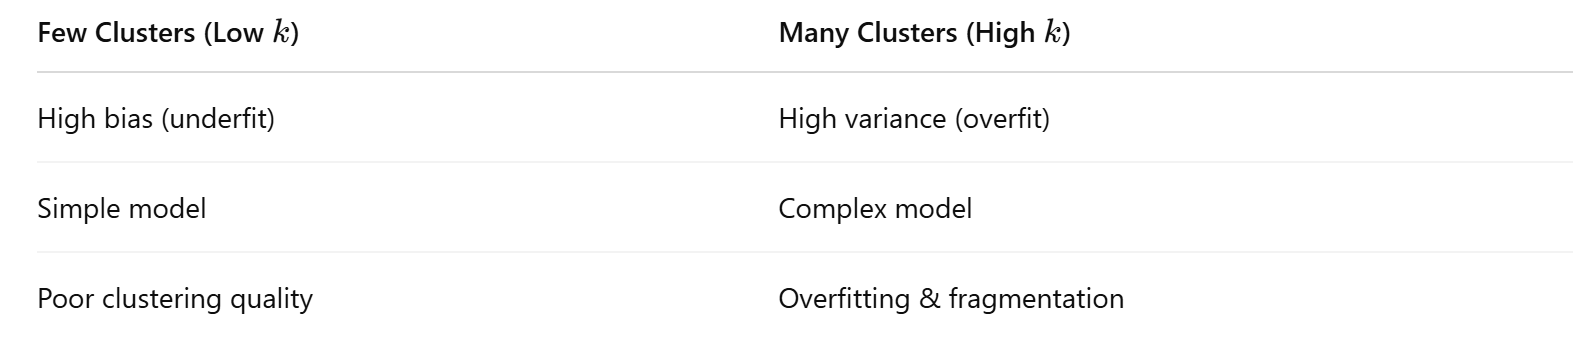



##### Challenge 4:

The K-Means algorithm is so sensitive to outliers. Outliers can change the data sample of a cluster in a very wrong way. We should delete or ignore these outliers as we start training K-means.

##### Challenge 5:

K-Means assumes clusters are spherical and separated by equal variance, which limits its effectiveness on non-spherical or complex-shaped cluster. This can be fixed by using other algorithms that were derived from K-Means or other clustering algorithms that have fixed this issue, You will be able to be introduced to some of them in the next part

> So K-Means is sensitive to the distribution of data samples and it cannot handle all the distributions possible (mostly can handle sepherical separated ones).

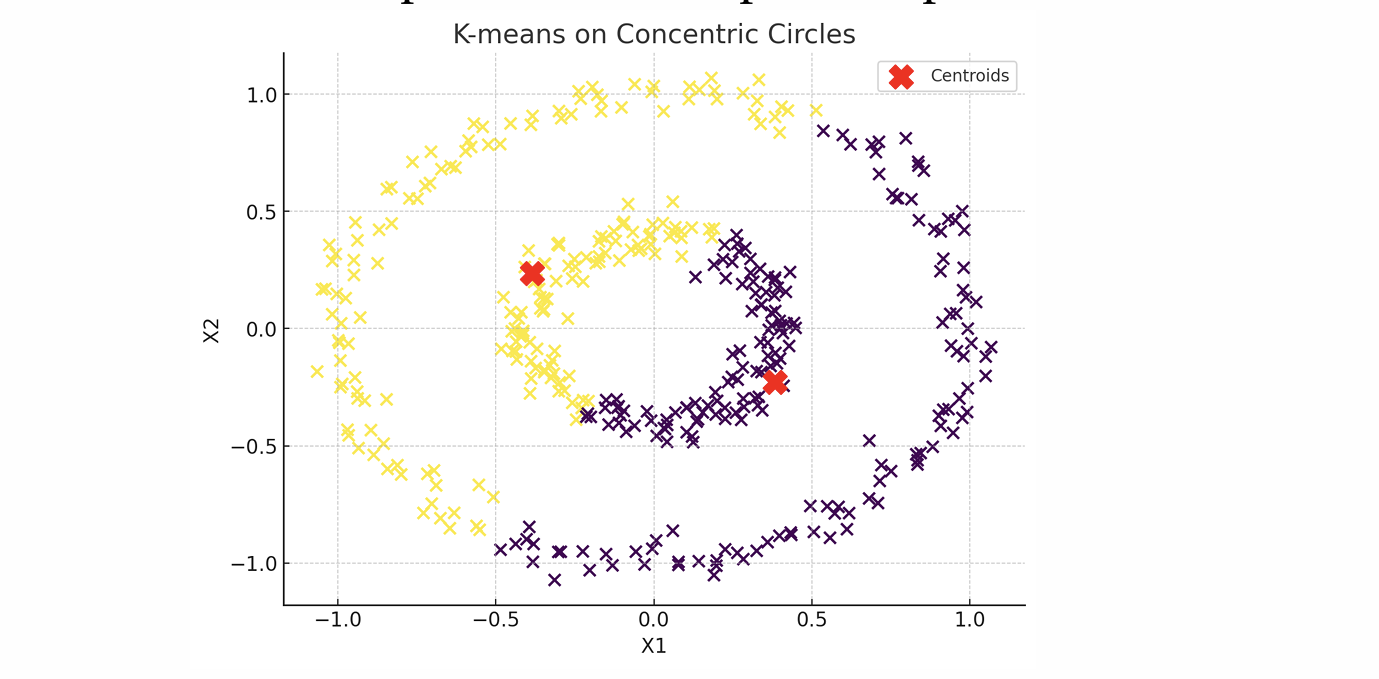
<center>Figure 5: misclustered due to a different data distribution, Adopted from [2]</center>

### References:

[1] [Clustering, IBM](https://www.ibm.com/think/topics/clustering)<br>
[2] [Kmeans slide, ML course, sharif university](https://github.com/SharifiZarchi/Introduction_to_Machine_Learning/blob/main/Slides/Chapter_02_Unsupervised_Learning/01-Clustering/02-01-KMeans.pdf)<br>
[3] [K-Means++ Initializatin Algorithm, GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/ml-k-means-algorithm/)<br>
[4] [K-Modes Clustering, GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/k-mode-clustering-in-python/)<br>
[5] [K-Modes, youtube video](https://www.youtube.com/watch?v=b39_vipRkUo)<br>
[6] [Hamming Distance, datacamp](https://www.datacamp.com/tutorial/hamming-distance) <br>
